In [ ]:
!pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.1/112.6 GB disk)


In [ ]:
!wget -q https://github.com/ultralytics/assets/releases/download/v0.0.0/coco8.zip
!unzip -q coco8.zip
print("Dataset ready!")

Dataset ready!


In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8s.pt')

results = model.train(
    data='coco8.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    project='pedestrian_detection',
    name='yolov8s_run1',
    save=True
)

print("Training complete!")

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_run1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/runs/detect/pedestrian_detection/yolov8s_run1/results.csv')
df.columns = df.columns.str.strip()
print("Final metrics:")
print(df[['epoch', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)']].tail(5))

Final metrics:
    epoch  metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)
45     46               0.91237            0.55072           0.85400
46     47               0.97462            0.52290           0.76897
47     48               0.97462            0.52290           0.76897
48     49               0.97397            0.52282           0.76003
49     50               0.97397            0.52282           0.76003


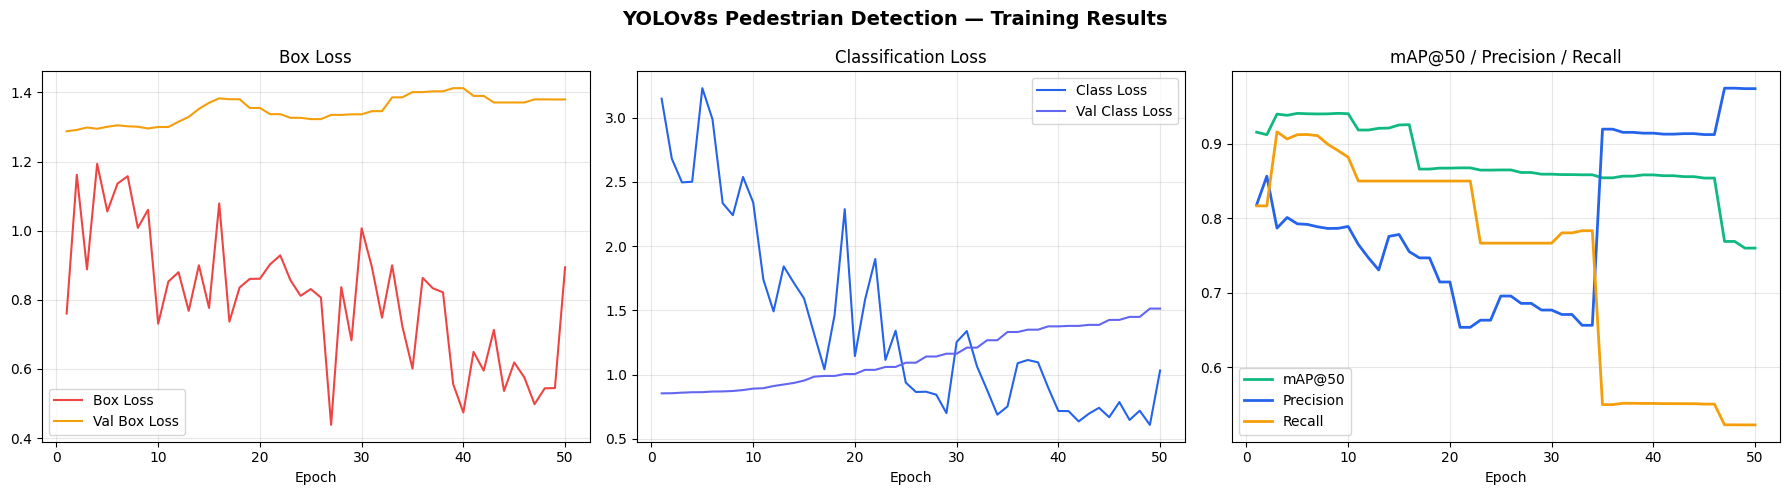

Loss curves saved!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(df['epoch'], df['train/box_loss'], label='Box Loss', color='#EF4444')
axes[0].plot(df['epoch'], df['val/box_loss'], label='Val Box Loss', color='#F59E0B')
axes[0].set_title('Box Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df['epoch'], df['train/cls_loss'], label='Class Loss', color='#2563EB')
axes[1].plot(df['epoch'], df['val/cls_loss'], label='Val Class Loss', color='#6366F1')
axes[1].set_title('Classification Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50', color='#10B981', lw=2)
axes[2].plot(df['epoch'], df['metrics/precision(B)'], label='Precision', color='#2563EB', lw=2)
axes[2].plot(df['epoch'], df['metrics/recall(B)'], label='Recall', color='#F59E0B', lw=2)
axes[2].set_title('mAP@50 / Precision / Recall')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

fig.suptitle('YOLOv8s Pedestrian Detection — Training Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print("Loss curves saved!")

In [ ]:
# Validate model and get PR curve
model = YOLO('/content/runs/detect/pedestrian_detection/yolov8s_run1/weights/best.pt')
metrics = model.val(data='coco8.yaml', device=0)

print("=" * 50)
print("YOUR FINAL RESULTS:")
print(f"Precision:  {metrics.box.mp:.3f}")
print(f"Recall:     {metrics.box.mr:.3f}")
print(f"mAP@50:     {metrics.box.map50:.3f}")
print(f"mAP@50-95:  {metrics.box.map:.3f}")
print("=" * 50)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,156,544 parameters, 0 gradients, 28.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1585.3±588.8 MB/s, size: 54.0 KB)
val: Scanning /content/coco8/labels/val.cache... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4 1.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 8.8it/s 0.1s
                   all          4         17      0.792      0.912      0.941      0.707
                person          3         10      0.847        0.6      0.669      0.361
                   dog          1          1      0.767          1      0.995      0.796
                 horse          1          2      0.782          1      0.995      0.795
              elephant          1          2          1      0.872      0.995      0.497
              umbrella          1          1      0.665     

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copytree(
    '/content/runs/detect/pedestrian_detection/yolov8s_run1',
    '/content/drive/MyDrive/dissertation_yolov8_results'
)
print("All results saved to your Google Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All results saved to your Google Drive!
